# 02. A/B Testing and Product Experimentation

A/B testing is randomized experimentation inside a product system. The statistical idea is simple: randomly assign eligible units to variants and compare outcomes. The operational reality is richer: users arrive continuously, assignments must be sticky, features are triggered only for some users, metrics have complicated denominators, logging can fail, and teams need a launch decision.

This notebook connects the clean randomized-experiment logic from the previous lecture to the messy world of product experimentation.

The central message is:

> A trustworthy A/B test is not just a p-value. It is a causal design, a reliable assignment system, a metric contract, and a decision process.

We will simulate a product experiment end to end. Along the way we will cover sticky assignment, primary and guardrail metrics, sample-ratio mismatch, A/A tests, user-level versus event-level analysis, triggered analysis, and variance reduction.

Online controlled experiments are widely used in web and software companies to evaluate product changes and guide decisions (Kohavi et al., 2008; Kohavi et al., 2013). The same causal principles apply whether the product is a marketplace, SaaS platform, recommender system, search engine, education platform, or AI product.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain how an A/B test differs from a generic randomized experiment.
- Implement stable hash-based assignment for a product experiment simulation.
- Distinguish assignment, exposure, triggering, and outcome measurement.
- Build a user-level metric readout with primary, secondary, guardrail, and invariant metrics.
- Detect sample-ratio mismatch and explain why it matters.
- Explain why event-level rows can understate uncertainty when assignment is user-level.
- Compare intent-to-treat and triggered-user estimands.
- Use A/A simulations to understand false positives and platform validation.
- Apply pre-experiment covariates for variance reduction without changing the causal estimand.
- Create a practical launch readout for product stakeholders.

## Mathematical Setup: Assignment, Metrics, and Precision

A product A/B test is a randomized design with operational details around it. Let $Z_i$ denote assignment for unit $i$, where $Z_i=1$ means treatment and $Z_i=0$ means control. For a planned treatment share $p$:

$$
Z_i \sim \text{Bernoulli}(p)
$$

The basic intent-to-treat estimand is:

$$
\tau_{ITT} = E[Y_i(1) - Y_i(0)]
$$

The usual difference-in-means estimator is:

$$
\widehat{\tau}_{ITT} = \bar{Y}_{Z=1} - \bar{Y}_{Z=0}
$$

A large-sample standard error for a continuous metric is:

$$
SE(\widehat{\tau}_{ITT}) = \sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}}
$$

Sample-ratio mismatch checks whether assignment counts match the planned probabilities. With observed counts $O_a$ and expected counts $E_a$, the diagnostic statistic is:

$$
\chi^2 = \sum_a \frac{(O_a - E_a)^2}{E_a}
$$

Triggered analyses change the target population. If $T_i=1$ indicates that a user reached the treatment surface, the triggered estimand is:

$$
E[Y_i(1) - Y_i(0) \mid T_i=1]
$$

This quantity is useful, while the full eligible-population launch effect is a different estimand.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "assignment": "#d7ecff",
    "metric": "#ffd6db",
    "covariate": "#dff0d8",
    "guardrail": "#ffe0c2",
    "process": "#eadcf8",
    "warning": "#fff1c7",
    "neutral": "#f7f7f7",
}

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.55", ranksep="0.65")
    dot.attr("node", shape="box", style="rounded,filled", color="#2b2b2b", fontname="Helvetica", fontsize="11", margin="0.12,0.08")
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            attrs = {}
        else:
            src, dst, attrs = edge
        dot.edge(src, dst, **attrs)
    return dot


def stable_uniform_01(unit_id, salt):
    """
    Convert a unit identifier into a stable pseudo-random assignment score.
    
    Idea:
        Hash-based assignment keeps a user in the same arm across repeated runs of the notebook and mirrors production A/B testing practice.
    
    Args:
        unit_id: Stable user, account, or unit identifier used for deterministic assignment.
        salt: Experiment-specific string that changes assignments across experiments while keeping them reproducible.
    
    Returns:
        float: Deterministic number in the half-open interval [0, 1).
    """
    key = f"{salt}:{unit_id}".encode("utf-8")
    digest = hashlib.sha256(key).hexdigest()[:16]
    return int(digest, 16) / 16**16


def assign_variant(unit_ids, salt="experiment", treatment_fraction=0.5):
    """Assign product users to variants with a stable hash-based rule.

    Args:
        unit_ids: Stable unit identifiers used for deterministic assignment.
        salt: Experiment-specific salt used to make hash assignment reproducible.
        treatment_fraction: Share of units assigned to treatment.

    Returns:
        pandas.DataFrame or numpy.ndarray: Copy of the data with the requested assignment or derived variables added.
    """
    buckets = np.array([stable_uniform_01(uid, salt) for uid in unit_ids])
    return (buckets < treatment_fraction).astype(int), buckets


def difference_in_means(y, z):
    """Compute the treated-minus-control difference in sample means.

    Args:
        y: Outcome vector used in the comparison or adjustment.
        z: Assignment or instrument vector used to define comparison groups.

    Returns:
        float: Treated-minus-control mean difference.
    """
    y = np.asarray(y)
    z = np.asarray(z)
    return y[z == 1].mean() - y[z == 0].mean()


def two_sample_se(y, z):
    """Compute a classical two-sample standard error for a difference in means.

    Args:
        y: Outcome vector used in the comparison or adjustment.
        z: Assignment or instrument vector used to define comparison groups.

    Returns:
        float: Standard error for the two-sample mean difference.
    """
    y = np.asarray(y)
    z = np.asarray(z)
    y1 = y[z == 1]
    y0 = y[z == 0]
    return np.sqrt(y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0))


def metric_readout(df, metric, z_col="Z", higher_is_better=True):
    """Create a metric-level experiment readout with lift, uncertainty, and directionality.

    Args:
        df: Analysis DataFrame used by the helper.
        metric: Metric column being estimated or tested.
        z_col: Column name containing treatment assignment.
        higher_is_better: Whether an increase in the metric is desirable.

    Returns:
        dict: Metric estimate, uncertainty, p-value, and decision direction.
    """
    z = df[z_col].to_numpy()
    y = df[metric].to_numpy()
    est = difference_in_means(y, z)
    se = two_sample_se(y, z)
    p_value = 2 * (1 - stats.norm.cdf(abs(est / se)))
    control_mean = y[z == 0].mean()
    treatment_mean = y[z == 1].mean()
    rel_lift = est / control_mean if control_mean != 0 else np.nan
    return {
        "metric": metric,
        "control_mean": control_mean,
        "treatment_mean": treatment_mean,
        "difference": est,
        "relative_lift": rel_lift,
        "std_error": se,
        "ci_lower": est - 1.96 * se,
        "ci_upper": est + 1.96 * se,
        "p_value": p_value,
        "higher_is_better": higher_is_better,
    }


def sample_ratio_test(z, expected_treatment_fraction=0.5):
    """
    Test whether observed treatment allocation matches the planned experiment split.
    
    Idea:
        A sample-ratio mismatch can reveal instrumentation or randomization problems before outcome estimates are trusted.
    
    Args:
        z: Binary assignment or instrument indicator.
        expected_treatment_fraction: Planned fraction of units assigned to the treatment arm.
    
    Returns:
        dict: Observed counts, expected counts, chi-square statistic, and p-value.
    """
    observed = np.array([(z == 0).sum(), (z == 1).sum()])
    n = observed.sum()
    expected = np.array([1 - expected_treatment_fraction, expected_treatment_fraction]) * n
    chi2, p_value = stats.chisquare(observed, f_exp=expected)
    return pd.DataFrame({
        "arm": ["control", "treatment"],
        "observed": observed,
        "expected": expected,
        "observed_share": observed / n,
        "expected_share": expected / n,
        "chi2": [chi2, chi2],
        "p_value": [p_value, p_value],
    })

## 1. The Product Experimentation Loop

A product A/B test usually has more moving pieces than a classroom randomized experiment.

A useful experimentation loop is:

1. **Decision**: identify the product decision the experiment will inform.
2. **Hypothesis**: state why the variant should change user behavior.
3. **Unit**: choose the randomization unit, such as user, account, seller, store, or market.
4. **Eligibility**: define who can enter the experiment.
5. **Assignment**: assign eligible units to variants using a stable randomization mechanism.
6. **Exposure**: record whether the user actually encountered the changed surface.
7. **Metrics**: compute primary, secondary, guardrail, and invariant metrics.
8. **Quality checks**: inspect sample-ratio mismatch, logging, missingness, and A/A behavior.
9. **Decision**: launch, iterate, ramp, or stop.

This is why product experimentation is a causal workflow, not just a statistical test.

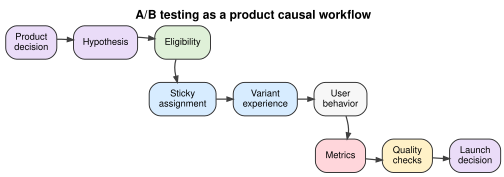

In [3]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_ab_testing_workflow(loop_colors):
    """
    Draw the A/B testing workflow used to organize launch, diagnostic, and readout steps.
    
    Idea:
        The workflow emphasizes that product experiments require assignment checks, guardrails, and interpretation before launch decisions.
    
    Args:
        loop_colors: Color palette used for the A/B testing workflow nodes.
    
    Returns:
        graphviz.Digraph: Curved workflow diagram ready for notebook display.
    """

    dot = Digraph(format="svg")
    dot.attr(
        bgcolor="transparent",
        pad="0.08",
        ranksep="0.35",
        nodesep="0.25",
        splines="curved",
        size="7,4",
    )
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        color="#2b2b2b",
        fontname="Helvetica",
        fontsize="10",
        margin="0.10,0.06",
    )
    dot.attr("edge", color="#404040", arrowsize="0.65", penwidth="1.3")
    dot.attr(
        label="A/B testing as a product causal workflow",
        labelloc="t",
        fontsize="13",
        fontname="Helvetica-Bold",
    )

    labels = {
        "product": "Product\ndecision",
        "hypothesis": "Hypothesis",
        "eligibility": "Eligibility",
        "assignment": "Sticky\nassignment",
        "experience": "Variant\nexperience",
        "behavior": "User\nbehavior",
        "metrics": "Metrics",
        "checks": "Quality\nchecks",
        "launch": "Launch\ndecision",
    }
    colors = {
        "product": loop_colors["Product decision"],
        "hypothesis": loop_colors["Hypothesis"],
        "eligibility": loop_colors["Eligibility"],
        "assignment": loop_colors["Sticky assignment"],
        "experience": loop_colors["Variant experience"],
        "behavior": loop_colors["User behavior"],
        "metrics": loop_colors["Metrics"],
        "checks": loop_colors["Quality checks"],
        "launch": loop_colors["Launch decision"],
    }

    for node, label in labels.items():
        dot.node(node, label=label, fillcolor=colors[node])

    for row in [
        ("product", "hypothesis", "eligibility"),
        ("assignment", "experience", "behavior"),
        ("metrics", "checks", "launch"),
    ]:
        with dot.subgraph() as rank:
            rank.attr(rank="same")
            for node in row:
                rank.node(node)

    workflow_edges = [
        ("product", "hypothesis"),
        ("hypothesis", "eligibility"),
        ("eligibility", "assignment"),
        ("assignment", "experience"),
        ("experience", "behavior"),
        ("behavior", "metrics"),
        ("metrics", "checks"),
        ("checks", "launch"),
    ]
    for source, target in workflow_edges:
        dot.edge(source, target)
    return dot


loop_colors = {
    "Product decision": COLORS["process"],
    "Hypothesis": COLORS["process"],
    "Eligibility": COLORS["covariate"],
    "Sticky assignment": COLORS["assignment"],
    "Variant experience": COLORS["assignment"],
    "User behavior": COLORS["neutral"],
    "Metrics": COLORS["metric"],
    "Quality checks": COLORS["warning"],
    "Launch decision": COLORS["process"],
}

smart_display(make_ab_testing_workflow(loop_colors))

### A/B Test Vocabulary

| Term | Meaning | Why it matters |
|---|---|---|
| Unit of randomization | Entity assigned to variants | Determines independence and causal contrast |
| Assignment | The variant a unit is allocated to | Basis for intent-to-treat analysis |
| Exposure | Whether the unit actually saw/received the feature | Often differs from assignment |
| Triggering | Whether the unit reached the product surface where treatment can act | Defines a narrower estimand if used for analysis |
| Primary metric | Main decision metric | Prevents metric shopping |
| Guardrail metric | Metric that should not degrade | Protects user experience and business constraints |
| Invariant metric | Metric that should not move if randomization/logging works | Detects bugs and selection issues |
| Sample-ratio mismatch | Observed treatment split differs from planned split | Often indicates implementation or logging problems |

Kohavi et al. (2008) and Crook et al. (2009) emphasize that trustworthy online experiments depend on both statistical design and implementation discipline.

## 2. Sticky Hash-Based Assignment

In online products, users arrive over time. The system needs stable assignment: the same user should see the same variant across visits unless the experiment design says otherwise.

A common approach is to hash a stable unit identifier with an experiment salt. The hash produces a pseudo-random number between 0 and 1. Users below the treatment threshold enter treatment; others enter control.

This gives three practical properties:

- **Stable**: the same user receives the same assignment for the same experiment salt.
- **Random-looking**: assignments are approximately balanced across many users.
- **Independent across experiments**: changing the salt reshuffles users for a different experiment.

Large-scale experimentation platforms use related ideas for consistent assignment and concurrent experiments (Kohavi et al., 2013).

In [4]:
# Assemble the Sticky Hash-Based Assignment summary table used for interpretation.
example_users = np.arange(1, 11)
assign_a, bucket_a = assign_variant(example_users, salt="onboarding_v1", treatment_fraction=0.5)
assign_a_again, bucket_a_again = assign_variant(example_users, salt="onboarding_v1", treatment_fraction=0.5)
assign_b, bucket_b = assign_variant(example_users, salt="pricing_banner_v1", treatment_fraction=0.5)

assignment_demo = pd.DataFrame({
    "user_id": example_users,
    "bucket_onboarding": bucket_a,
    "assignment_onboarding": np.where(assign_a == 1, "treatment", "control"),
    "same_assignment_when_recomputed": assign_a == assign_a_again,
    "assignment_different_experiment_salt": np.where(assign_b == 1, "treatment", "control"),
})
smart_display(assignment_demo)

,user_id,bucket_onboarding,assignment_onboarding,same_assignment_when_recomputed,assignment_different_experiment_salt
0,1,0.365815,treatment,True,treatment
1,2,0.854909,control,True,treatment
2,3,0.681133,control,True,control
3,4,0.716019,control,True,treatment
4,5,0.435041,treatment,True,control
5,6,0.338960,treatment,True,treatment
6,7,0.872992,control,True,treatment
7,8,0.566229,control,True,control
8,9,0.252782,treatment,True,treatment
9,10,0.465455,treatment,True,treatment


In Sticky Hash-Based Assignment, the table is a design check. Outcome interpretation comes after the assignment table looks consistent with the design.

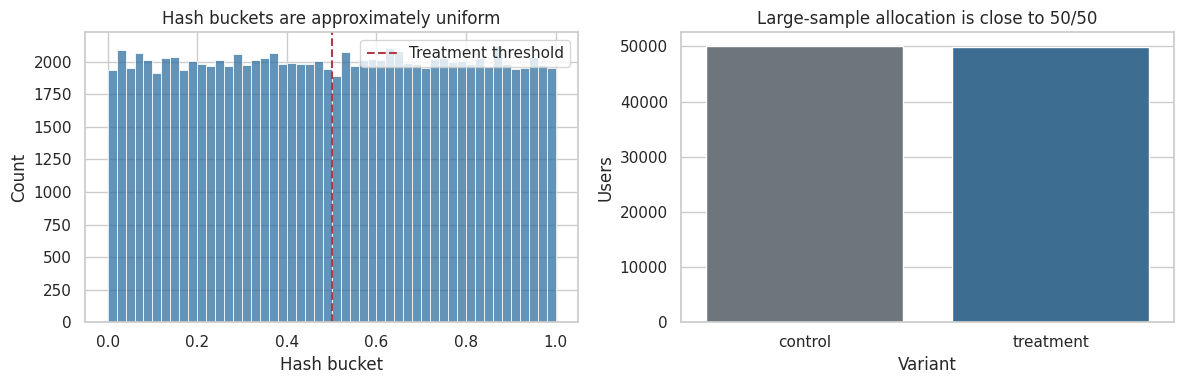

,arm,observed,expected,observed_share,expected_share,chi2,p_value
0,control,50064,50000.0,0.5006,0.5,0.1638,0.6856
1,treatment,49936,50000.0,0.4994,0.5,0.1638,0.6856


In [5]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
large_users = np.arange(100_000)
large_assign, large_buckets = assign_variant(large_users, salt="onboarding_v1", treatment_fraction=0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(large_buckets, bins=50, color="#2f6f9f", ax=axes[0])
axes[0].axvline(0.5, color="#b23a48", linestyle="--", label="Treatment threshold")
axes[0].set_title("Hash buckets are approximately uniform")
axes[0].set_xlabel("Hash bucket")
axes[0].legend()

counts = pd.Series(large_assign).map({0: "control", 1: "treatment"}).value_counts().reindex(["control", "treatment"])
sns.barplot(x=counts.index, y=counts.values, ax=axes[1], palette=["#6c757d", "#2f6f9f"])
axes[1].set_title("Large-sample allocation is close to 50/50")
axes[1].set_ylabel("Users")
axes[1].set_xlabel("Variant")

plt.tight_layout()
plt.show()

sample_ratio_test(large_assign).round(4)

The buckets are close to uniform, and the treatment-control split is close to the planned 50/50 allocation. In a real platform, the exact implementation would be production-grade and carefully audited, but the conceptual structure is the same.

The experiment salt matters. If two experiments use the same salt and threshold, assignments can be perfectly correlated. If experiments overlap and interact, that can complicate interpretation. Experiment platforms therefore need namespace management, traffic allocation rules, and interaction checks.

## 3. Simulating a Product A/B Test

We will simulate a SaaS onboarding experiment. The product team wants to test a new checklist shown to eligible accounts. The primary outcome is 14-day value per account. The treatment only has a chance to affect users who reach the onboarding surface.

The data-generating process includes:

- pre-experiment account value;
- account segment;
- platform;
- whether the account reaches the onboarding surface;
- potential outcomes under control and treatment assignment;
- guardrail outcomes such as latency and support tickets.

The estimand for the main readout is the **intent-to-treat effect of assignment** among eligible accounts. That is the effect of assigning the new checklist, whether or not a user reaches the surface.

**Dataset and experiment setup.** The simulated A/B test represents users of a digital product. Assignment is sticky, meaning the same user keeps the same variant across sessions. The unit of randomization is the user, while some outcomes are generated at the session or event level. This distinction matters because product teams often log many events per user and then accidentally analyze them as independent observations. The generated experiment includes primary metrics, guardrails, invariants, triggering, and pre-experiment behavior so the notebook can teach not just estimation, but experiment-readiness checks.

In [6]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def create_product_population(n=60_000, seed=11):
    """Create the product population dataset or diagnostic object used in 02. A/B Testing and Product Experimentation.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Generated or modified dataset used in the next lecture section.
    """
    rng_local = np.random.default_rng(seed)
    user_id = np.arange(n)
    segment = rng_local.choice(["new", "growing", "power"], size=n, p=[0.50, 0.35, 0.15])
    platform = rng_local.choice(["web", "ios", "android"], size=n, p=[0.55, 0.25, 0.20])
    pre_value = rng_local.lognormal(mean=2.1, sigma=0.65, size=n)
    prior_sessions = rng_local.poisson(lam=np.clip(1.8 + 0.25 * np.log1p(pre_value), 0.5, 8.0), size=n)
    is_team = rng_local.binomial(1, 0.32, size=n)

    segment_effect = pd.Series(segment).map({"new": -1.5, "growing": 1.0, "power": 3.2}).to_numpy()
    platform_effect = pd.Series(platform).map({"web": 0.6, "ios": 0.2, "android": -0.1}).to_numpy()

    trigger_score = -0.85 + 0.22 * np.log1p(pre_value) + 0.45 * (segment == "new") + 0.25 * is_team
    p_trigger = 1 / (1 + np.exp(-trigger_score))
    would_trigger = rng_local.binomial(1, p_trigger)

    y0_value = (
        8.0
        + 1.8 * np.log1p(pre_value)
        + 0.55 * prior_sessions
        + 1.2 * is_team
        + segment_effect
        + platform_effect
        + rng_local.normal(scale=4.0, size=n)
    )

    individual_effect_if_triggered = (
        0.9
        + 1.0 * (segment == "new")
        + 0.35 * is_team
        - 0.10 * np.log1p(pre_value)
    )
    assignment_effect = would_trigger * individual_effect_if_triggered
    y1_value = y0_value + assignment_effect

    conv0_latent = -1.2 + 0.22 * np.log1p(pre_value) + 0.15 * prior_sessions + 0.20 * is_team + 0.25 * (segment == "new")
    p_conv0 = 1 / (1 + np.exp(-conv0_latent))
    p_conv1 = np.clip(p_conv0 + would_trigger * (0.018 + 0.010 * (segment == "new")), 0, 1)
    conversion0 = rng_local.binomial(1, p_conv0)
    conversion1 = rng_local.binomial(1, p_conv1)

    latency0 = 190 + 8 * (platform == "android") + 4 * (platform == "ios") + rng_local.normal(scale=22, size=n)
    latency1 = latency0 + would_trigger * (7 + 3 * (platform == "android")) + rng_local.normal(scale=4, size=n)

    support0 = rng_local.binomial(1, np.clip(0.035 + 0.015 * (segment == "new"), 0, 1))
    support1 = rng_local.binomial(1, np.clip(0.035 + 0.015 * (segment == "new") + would_trigger * 0.004, 0, 1))

    return pd.DataFrame({
        "user_id": user_id,
        "segment": segment,
        "platform": platform,
        "pre_value": pre_value,
        "prior_sessions": prior_sessions,
        "is_team": is_team,
        "would_trigger": would_trigger,
        "Y0_value": y0_value,
        "Y1_value": y1_value,
        "conversion0": conversion0,
        "conversion1": conversion1,
        "latency0_ms": latency0,
        "latency1_ms": latency1,
        "support0": support0,
        "support1": support1,
        "individual_assignment_effect": assignment_effect,
        "individual_triggered_effect": individual_effect_if_triggered,
    })

product_pop = create_product_population()
product_pop["Z"], product_pop["bucket"] = assign_variant(product_pop["user_id"], salt="onboarding_checklist_v1", treatment_fraction=0.5)
product_pop["value_14d"] = np.where(product_pop["Z"] == 1, product_pop["Y1_value"], product_pop["Y0_value"])
product_pop["converted"] = np.where(product_pop["Z"] == 1, product_pop["conversion1"], product_pop["conversion0"])
product_pop["latency_ms"] = np.where(product_pop["Z"] == 1, product_pop["latency1_ms"], product_pop["latency0_ms"])
product_pop["support_ticket"] = np.where(product_pop["Z"] == 1, product_pop["support1"], product_pop["support0"])
product_pop["triggered"] = product_pop["would_trigger"]
product_pop["exposed"] = (product_pop["Z"] == 1) & (product_pop["triggered"] == 1)

true_itt = product_pop["individual_assignment_effect"].mean()
true_triggered_effect = product_pop.loc[product_pop["would_trigger"] == 1, "individual_triggered_effect"].mean()

pd.DataFrame({
    "quantity": ["Eligible users", "Trigger rate", "True ITT effect on value", "True effect among would-trigger users"],
    "value": [len(product_pop), product_pop["would_trigger"].mean(), true_itt, true_triggered_effect],
}).round(4)

,quantity,value
0,Eligible users,60000.0000
1,Trigger rate,0.4842
2,True ITT effect on value,0.6551
3,True effect among would-trigger users,1.3528


In Simulating a Product A/B Test, the table is a design check. A clean outcome readout starts with a clean assignment and balance check.

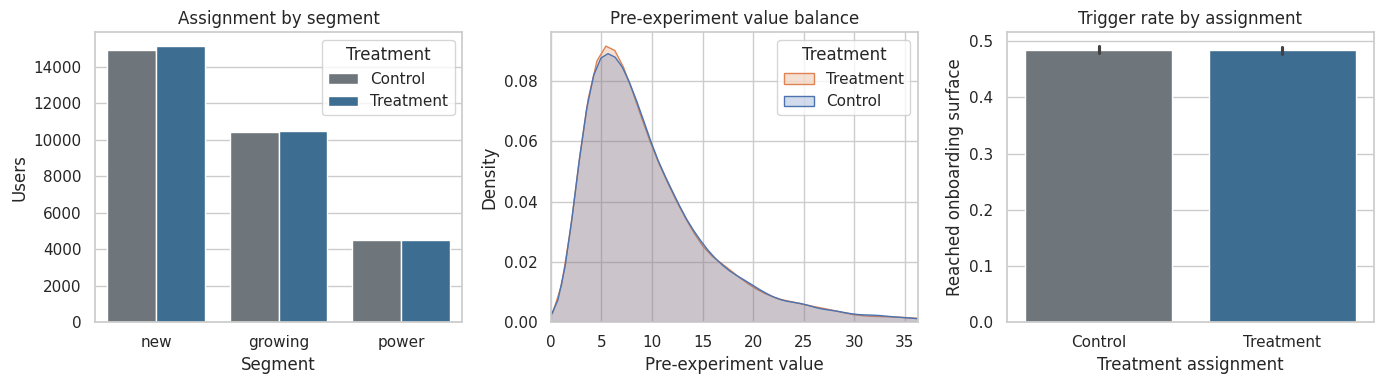

In [7]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=product_pop, x="segment", hue="Z", ax=axes[0], palette=["#6c757d", "#2f6f9f"])
axes[0].set_title("Assignment by segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Users")
axes[0].legend(title="Treatment", labels=["Control", "Treatment"])

sns.kdeplot(data=product_pop, x="pre_value", hue="Z", common_norm=False, fill=True, alpha=0.25, ax=axes[1])
axes[1].set_title("Pre-experiment value balance")
axes[1].set_xlabel("Pre-experiment value")
axes[1].set_xlim(0, product_pop["pre_value"].quantile(0.99))
axes[1].legend(title="Treatment", labels=["Treatment", "Control"])

sns.barplot(data=product_pop, x="Z", y="triggered", ax=axes[2], palette=["#6c757d", "#2f6f9f"])
axes[2].set_title("Trigger rate by assignment")
axes[2].set_xlabel("Treatment assignment")
axes[2].set_ylabel("Reached onboarding surface")
axes[2].set_xticklabels(["Control", "Treatment"])

plt.tight_layout()
plt.show()

The experiment is randomized at the user/account level. Segment and pre-experiment value are balanced across treatment arms, up to random noise. The trigger rate is also similar because triggering is based on pre-treatment behavior and product navigation that is not affected by assignment in this simulation.

Notice the distinction between:

- **assigned to treatment**: selected by randomization;
- **triggered**: reached the onboarding surface;
- **exposed**: assigned to treatment and reached the surface.

The primary experiment readout should usually start with assignment. That is the clean randomized contrast.

## 4. Metric Families: Primary, Secondary, Guardrail, Invariant

Product experiments should declare metric roles before analysis.

| Metric type | Purpose | Example |
|---|---|---|
| Primary decision metric | Main metric used to decide whether the change worked | 14-day value per account |
| Secondary metric | Helps explain where the effect came from | Conversion rate, activation rate |
| Guardrail metric | Must not degrade beyond tolerance | Latency, support tickets, refunds |
| Invariant metric | Should not move if randomization and logging are correct | Pre-experiment value, country mix, account age |

A common mistake is to inspect many metrics after the fact and promote whichever one looks best. That turns experimentation into storytelling. A good metric contract protects the interpretation.

In [8]:
# Assemble the Metric Families: Primary, Secondary, Guardrail, Invariant summary table used for interpretation.
metric_specs = pd.DataFrame([
    {"metric": "value_14d", "role": "primary", "higher_is_better": True},
    {"metric": "converted", "role": "secondary", "higher_is_better": True},
    {"metric": "latency_ms", "role": "guardrail", "higher_is_better": False},
    {"metric": "support_ticket", "role": "guardrail", "higher_is_better": False},
    {"metric": "pre_value", "role": "invariant", "higher_is_better": None},
])

readouts = []
for row in metric_specs.itertuples(index=False):
    readouts.append(metric_readout(product_pop, row.metric, higher_is_better=True if row.higher_is_better is None else row.higher_is_better))
metric_table = pd.DataFrame(readouts).merge(metric_specs[["metric", "role"]], on="metric")
metric_table[["role", "metric", "control_mean", "treatment_mean", "difference", "relative_lift", "std_error", "ci_lower", "ci_upper", "p_value"]].round(4)

,role,metric,control_mean,treatment_mean,difference,relative_lift,std_error,ci_lower,ci_upper,p_value
0,primary,value_14d,14.1518,14.7611,0.6093,0.0431,0.0375,0.5357,0.6828,0.0000
1,secondary,converted,0.4628,0.4738,0.0110,0.0238,0.0041,0.0030,0.0190,0.0069
2,guardrail,latency_ms,192.7114,196.3339,3.6225,0.0188,0.1843,3.2613,3.9837,0.0000
3,guardrail,support_ticket,0.0417,0.0465,0.0048,0.1155,0.0017,0.0015,0.0081,0.0041
4,invariant,pre_value,10.0711,10.0072,-0.0639,-0.0063,0.0596,-0.1808,0.0529,0.2834


In Metric Families: Primary, Secondary, Guardrail, Invariant, the table links the statistical evidence to the launch decision. Primary metrics, guardrails, and multiplicity answer different launch questions.

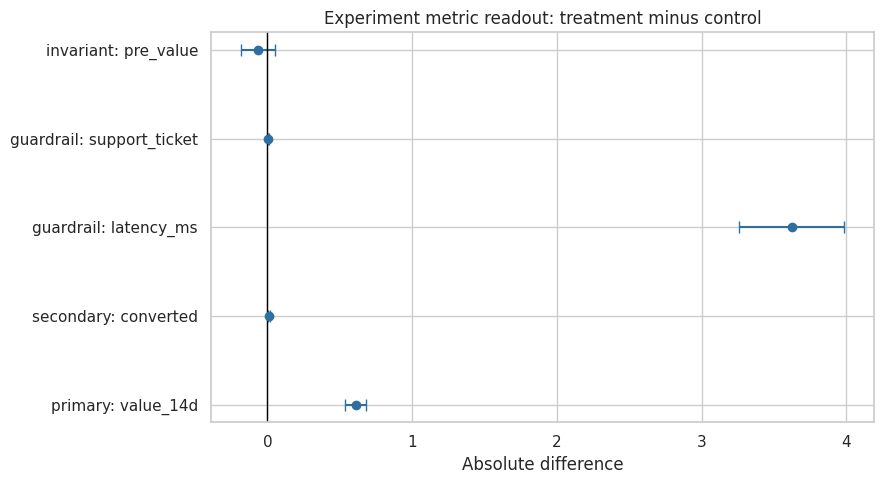

In [9]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
plot_metrics = metric_table.copy()
plot_metrics["label"] = plot_metrics["role"] + ": " + plot_metrics["metric"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    plot_metrics["difference"],
    plot_metrics["label"],
    xerr=[plot_metrics["difference"] - plot_metrics["ci_lower"], plot_metrics["ci_upper"] - plot_metrics["difference"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Experiment metric readout: treatment minus control")
ax.set_xlabel("Absolute difference")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

The primary metric improves because the checklist helps users who reach the onboarding surface. Conversion also improves modestly. Latency increases, which is a guardrail concern. Pre-experiment value should not move; if it did, we would suspect randomization, eligibility, or logging problems.

Product experimentation is therefore a decision problem with multiple constraints. A treatment can improve the primary metric and still be a bad launch if it damages guardrails.

## 5. Sample-Ratio Mismatch

Sample-ratio mismatch, often abbreviated SRM, occurs when the observed allocation differs materially from the planned allocation. For a planned 50/50 experiment, the treatment and control sample sizes should be close after randomization noise.

SRM does not tell us exactly what went wrong. It tells us the experiment may not be trustworthy until we investigate.

Possible causes include:

- broken hashing or bucketing;
- treatment-only logging failures;
- eligibility evaluated differently by variant;
- bot or crawler filtering that affects arms differently;
- client-side exposure bugs;
- data pipeline joins that drop one variant more often.

Automated SRM checks are common in mature experimentation platforms because they catch many data-quality failures early (Vermeer et al., 2022).

In [10]:
clean_srm = sample_ratio_test(product_pop["Z"].to_numpy(), expected_treatment_fraction=0.5)
clean_srm.round(4)

,arm,observed,expected,observed_share,expected_share,chi2,p_value
0,control,29914,30000.0,0.4986,0.5,0.4931,0.4826
1,treatment,30086,30000.0,0.5014,0.5,0.4931,0.4826


This result supports the section on Sample-Ratio Mismatch. It checks whether the experiment behaved like the design said it should. If assignment or baseline balance looks surprising, the problem is design credibility before it is metric interpretation.

In [11]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def create_srm_bug(df, seed=12):
    """Create a deliberate sample-ratio mismatch for platform-diagnostic teaching.

    Args:
        df: Analysis DataFrame used by this lecture step.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Generated or modified dataset used in the next lecture section.
    """
    rng_local = np.random.default_rng(seed)
    keep = np.ones(len(df), dtype=bool)
    # A simulated logging bug: some treatment users on iOS fail to appear in the analysis table.
    bug_mask = (df["Z"].to_numpy() == 1) & (df["platform"].to_numpy() == "ios") & (rng_local.random(len(df)) < 0.28)
    keep[bug_mask] = False
    return df.loc[keep].copy()

bugged = create_srm_bug(product_pop)
bug_srm = sample_ratio_test(bugged["Z"].to_numpy(), expected_treatment_fraction=0.5)
bug_srm.round(6)

,arm,observed,expected,observed_share,expected_share,chi2,p_value
0,control,29914,28922.0,0.51715,0.5,68.049512,0.0
1,treatment,27930,28922.0,0.48285,0.5,68.049512,0.0


In Sample-Ratio Mismatch, the table is a design check. If assignment counts or baseline balance look surprising, pause before interpreting outcomes.

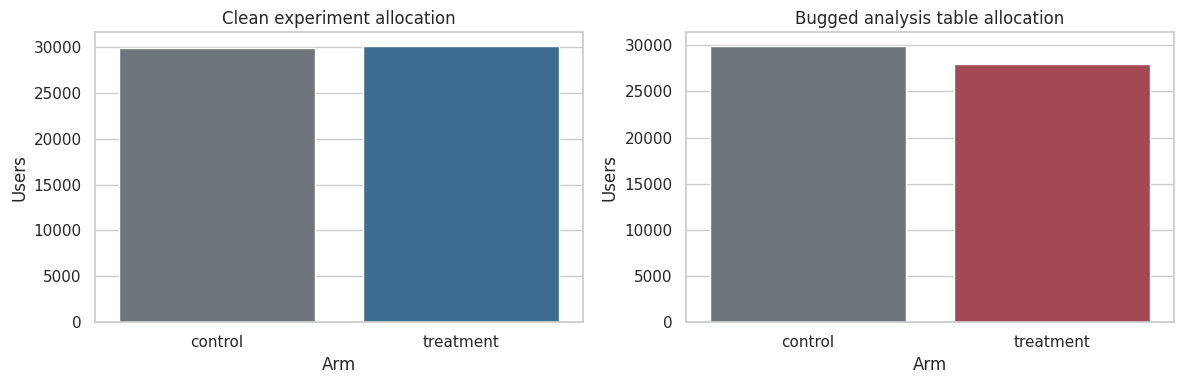

Z,control,treatment
platform,,
android,0.201,0.217
ios,0.249,0.198
web,0.550,0.586


In [12]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clean_counts = product_pop["Z"].map({0: "control", 1: "treatment"}).value_counts().reindex(["control", "treatment"])
sns.barplot(x=clean_counts.index, y=clean_counts.values, ax=axes[0], palette=["#6c757d", "#2f6f9f"])
axes[0].set_title("Clean experiment allocation")
axes[0].set_ylabel("Users")
axes[0].set_xlabel("Arm")

bug_counts = bugged["Z"].map({0: "control", 1: "treatment"}).value_counts().reindex(["control", "treatment"])
sns.barplot(x=bug_counts.index, y=bug_counts.values, ax=axes[1], palette=["#6c757d", "#b23a48"])
axes[1].set_title("Bugged analysis table allocation")
axes[1].set_ylabel("Users")
axes[1].set_xlabel("Arm")

plt.tight_layout()
plt.show()

pd.crosstab(bugged["platform"], bugged["Z"], normalize="columns").rename(columns={0: "control", 1: "treatment"}).round(3)

The clean experiment has an allocation close to 50/50. The bugged table shows a clear treatment shortfall. The platform mix is also distorted because the simulated bug drops some treatment users on iOS.

The lesson is operational: before reading the primary metric, check whether the experiment table itself looks like the assignment design. A significant SRM should usually pause interpretation until the cause is understood.

## 6. User-Level Assignment Means User-Level Analysis

Many product datasets are event-level: page views, sessions, impressions, searches, clicks, messages, or transactions. But if the experiment randomizes users, the independent experimental units are users, not rows.

Analyzing event rows as if each row were independently randomized can understate uncertainty because events from the same user are correlated. It can also change the estimand by weighting heavy users more.

The safest default is to aggregate to the randomization unit before computing experiment metrics. If event-level modeling is necessary, use appropriate clustered standard errors or a design-aware estimator.

In [13]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_session_events(users, seed=13):
    """Generate the synthetic session events data used in 02. A/B Testing and Product Experimentation.

    Args:
        users: User-level experiment DataFrame used to generate sessions.
        seed: Random seed used for reproducibility.

    Returns:
        pandas.DataFrame: Session-level events linked back to user assignment.
    """
    rng_local = np.random.default_rng(seed)
    n_users = len(users)
    session_counts = rng_local.poisson(lam=np.clip(1.2 + 0.18 * np.log1p(users["pre_value"]), 1.0, 10.0)).astype(int) + 1
    repeated = users.loc[users.index.repeat(session_counts)].copy()
    repeated["session_id"] = repeated.groupby("user_id").cumcount()
    user_random_effect = rng_local.normal(scale=2.5, size=n_users)
    repeated["user_effect"] = np.repeat(user_random_effect, session_counts)
    repeated["session_value"] = (
        2.0
        + 0.20 * np.log1p(repeated["pre_value"])
        + 0.35 * repeated["Z"] * repeated["triggered"]
        + repeated["user_effect"]
        + rng_local.normal(scale=2.2, size=len(repeated))
    )
    return repeated

session_users = product_pop.sample(8_000, random_state=13).copy()
session_events = simulate_session_events(session_users)

user_level = session_events.groupby(["user_id", "Z"], as_index=False).agg(
    mean_session_value=("session_value", "mean"),
    total_session_value=("session_value", "sum"),
    sessions=("session_id", "count"),
)

user_model = smf.ols("mean_session_value ~ Z", data=user_level).fit(cov_type="HC1")
event_naive_model = smf.ols("session_value ~ Z", data=session_events).fit(cov_type="HC1")
event_cluster_model = smf.ols("session_value ~ Z", data=session_events).fit(
    cov_type="cluster", cov_kwds={"groups": session_events["user_id"]}
)

unit_table = pd.DataFrame({
    "analysis": ["User-level mean", "Event-level naive SE", "Event-level clustered SE"],
    "estimate": [user_model.params["Z"], event_naive_model.params["Z"], event_cluster_model.params["Z"]],
    "std_error": [user_model.bse["Z"], event_naive_model.bse["Z"], event_cluster_model.bse["Z"]],
    "rows_used": [len(user_level), len(session_events), len(session_events)],
})
unit_table.round(4)

,analysis,estimate,std_error,rows_used
0,User-level mean,0.1654,0.0654,8000
1,Event-level naive SE,0.1663,0.0461,20596
2,Event-level clustered SE,0.1663,0.0691,20596


In User-Level Assignment Means User-Level Analysis, the model output should respect the randomization unit. If the table treats repeated events as independent users, the standard errors can become too optimistic.

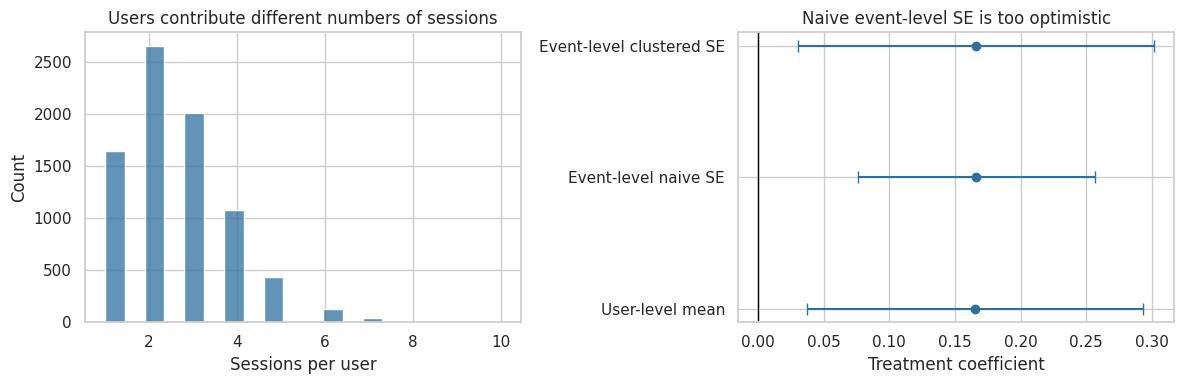

In [14]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(user_level["sessions"], bins=20, color="#2f6f9f", ax=axes[0])
axes[0].set_title("Users contribute different numbers of sessions")
axes[0].set_xlabel("Sessions per user")

plot_df = unit_table.copy()
plot_df["lower"] = plot_df["estimate"] - 1.96 * plot_df["std_error"]
plot_df["upper"] = plot_df["estimate"] + 1.96 * plot_df["std_error"]
axes[1].errorbar(
    plot_df["estimate"],
    plot_df["analysis"],
    xerr=[plot_df["estimate"] - plot_df["lower"], plot_df["upper"] - plot_df["estimate"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Naive event-level SE is too optimistic")
axes[1].set_xlabel("Treatment coefficient")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The event-level naive standard error is smaller because it treats correlated sessions from the same user as independent evidence. The clustered standard error moves back toward the user-level uncertainty.

In product work, this is a constant source of accidental overconfidence. The analysis unit should match the randomization unit unless there is a carefully justified alternative.

## 7. Triggered Analysis and Estimands

Many users assigned to an experiment never reach the surface where the treatment can affect them. This creates a distinction between:

- **Intent-to-treat (ITT)**: effect of assignment among all eligible users.
- **Triggered-user effect**: effect among users who reached the relevant surface.

The ITT is usually the cleanest primary readout because assignment is randomized for all eligible users. Triggered analysis can be useful for sensitivity and diagnosis, but it changes the population.

Triggered analysis is most defensible when triggering is defined symmetrically and pre-treatment with respect to the variant experience, such as reaching a page where either control or treatment could have been shown. It becomes risky when the trigger is itself affected by treatment, such as clicking a treatment-specific button.

In [15]:
# Assemble the Triggered Analysis and Estimands summary table used for interpretation.
itt_readout = metric_readout(product_pop, "value_14d")
triggered_readout = metric_readout(product_pop.query("triggered == 1"), "value_14d")

triggered_table = pd.DataFrame([
    {"estimand": "ITT among all eligible users", **itt_readout, "true_target": true_itt},
    {"estimand": "Triggered-user effect", **triggered_readout, "true_target": true_triggered_effect},
])
triggered_table[["estimand", "control_mean", "treatment_mean", "difference", "std_error", "ci_lower", "ci_upper", "true_target"]].round(4)

,estimand,control_mean,treatment_mean,difference,std_error,ci_lower,ci_upper,true_target
0,ITT among all eligible users,14.1518,14.7611,0.6093,0.0375,0.5357,0.6828,0.6551
1,Triggered-user effect,14.0410,15.3555,1.3145,0.0532,1.2101,1.4188,1.3528


In Triggered Analysis and Estimands, the table separates assignment from actual treatment receipt. That distinction tells the team whether the problem is the invitation, the treatment, or uptake.

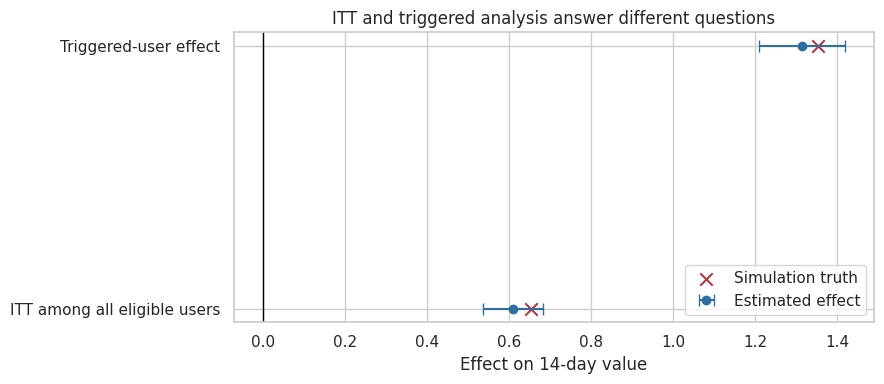

In [16]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = triggered_table.copy()
ax.errorbar(
    plot_df["difference"],
    plot_df["estimand"],
    xerr=[plot_df["difference"] - plot_df["ci_lower"], plot_df["ci_upper"] - plot_df["difference"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
    label="Estimated effect",
)
ax.scatter(plot_df["true_target"], plot_df["estimand"], color="#b23a48", marker="x", s=80, label="Simulation truth")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("ITT and triggered analysis answer different questions")
ax.set_xlabel("Effect on 14-day value")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

The triggered-user effect is larger because it focuses on users who actually reached the surface. The ITT is smaller because it averages in eligible users who could not be affected by the checklist during the experiment window.

Both quantities can be useful. The mistake is to report the triggered effect as if it were the full-population launch effect. A launch decision often needs both: the ITT for business impact and the triggered-user effect for product mechanism understanding.

## 8. A/A Tests: Validating the Experimentation Platform

An A/A test assigns users to two groups but gives them the same experience. If the platform and analysis are working, p-values for true null metrics should be approximately uniform across many independent A/A tests, and about 5% should be significant at the 5% level.

A/A tests are useful for checking:

- randomization implementation;
- metric computation;
- standard error calibration;
- logging asymmetries;
- false-positive expectations.

An A/A test cannot prove the platform is perfect, but it can catch many problems before teams trust A/B decisions.

In [17]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def run_aa_simulations(base_df, metric="Y0_value", n_sims=800, n_users=4_000, seed=14):
    """Run the aa simulations workflow used in 02. A/B Testing and Product Experimentation.

    Args:
        base_df: Baseline DataFrame used as the source for repeated simulations.
        metric: Metric column being estimated or tested.
        n_sims: Number of simulation repetitions.
        n_users: Number of users sampled in each A/A simulation.
        seed: Random seed used for reproducibility.

    Returns:
        pandas.DataFrame: A/A simulation estimates and p-values.
    """
    rng_local = np.random.default_rng(seed)
    p_values = []
    estimates = []
    for i in range(n_sims):
        sample = base_df.sample(n_users, replace=False, random_state=int(rng_local.integers(0, 2**32 - 1))).copy()
        z = rng_local.binomial(1, 0.5, size=n_users)
        y = sample[metric].to_numpy()
        est = difference_in_means(y, z)
        se = two_sample_se(y, z)
        p = 2 * (1 - stats.norm.cdf(abs(est / se)))
        p_values.append(p)
        estimates.append(est)
    return pd.DataFrame({"estimate": estimates, "p_value": p_values})

aa = run_aa_simulations(product_pop)

pd.DataFrame({
    "quantity": ["Share p < 0.05", "Mean A/A estimate", "SD of A/A estimates"],
    "value": [(aa["p_value"] < 0.05).mean(), aa["estimate"].mean(), aa["estimate"].std()],
}).round(4)

,quantity,value
0,Share p < 0.05,0.0550
1,Mean A/A estimate,0.0044
2,SD of A/A estimates,0.1453


In A/A Tests: Validating the Experimentation Platform, the figure should look boring. When no treatment exists, a healthy platform should mostly produce null-looking results.

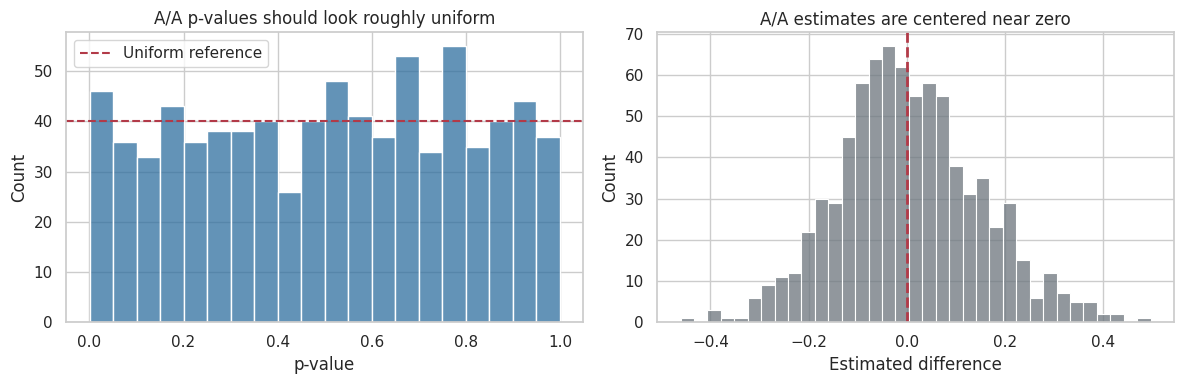

In [18]:
# Build the A/A Tests: Validating the Experimentation Platform plot from the quantities computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(aa["p_value"], bins=20, color="#2f6f9f", ax=axes[0])
axes[0].axhline(len(aa) / 20, color="#b23a48", linestyle="--", label="Uniform reference")
axes[0].set_title("A/A p-values should look roughly uniform")
axes[0].set_xlabel("p-value")
axes[0].legend()

sns.histplot(aa["estimate"], bins=35, color="#6c757d", ax=axes[1])
axes[1].axvline(0, color="#b23a48", linestyle="--", linewidth=2)
axes[1].set_title("A/A estimates are centered near zero")
axes[1].set_xlabel("Estimated difference")

plt.tight_layout()
plt.show()

The A/A estimates are centered near zero, and the p-values are roughly uniform. A small fraction of p-values fall below 0.05 even when there is no effect. That is not a bug; it is the expected false-positive rate.

This is a good moment to remind ourselves: a single significant result is not a complete decision. It must be interpreted with the design, metric plan, guardrails, and experiment quality checks.

## 9. Variance Reduction with Pre-Experiment Data

A/B tests can be slow when outcomes are noisy. One common way to improve sensitivity is to use pre-experiment covariates that predict the outcome but are unaffected by treatment.

CUPED-style adjustment uses a pre-period metric $X$ to transform the outcome:

$$
Y_i^{adj} = Y_i - \theta(X_i - \bar{X}),
$$

where

$$
\theta = \frac{\operatorname{Cov}(Y, X)}{\operatorname{Var}(X)}.
$$

Because $X$ is measured before randomization, this adjustment does not create post-treatment bias. If $X$ strongly predicts $Y$, it can reduce variance (Deng & Yu, 2015; Wong et al., 2019).

In [19]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def cuped_adjust(y, x):
    """Residualize an outcome on a pre-period covariate for CUPED-style variance reduction.

    Args:
        y: Outcome vector used in the calculation.
        x: Pre-period covariate or numeric predictor used in the calculation.

    Returns:
        numpy.ndarray: CUPED-adjusted outcome residuals shifted back to the original mean scale.
    """
    y = np.asarray(y)
    x = np.asarray(x)
    theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
    y_adj = y - theta * (x - x.mean())
    return y_adj, theta

cuped_df = product_pop.copy()
cuped_df["value_14d_cuped"], theta = cuped_adjust(cuped_df["value_14d"], cuped_df["pre_value"])

plain = metric_readout(cuped_df, "value_14d")
adjusted = metric_readout(cuped_df, "value_14d_cuped")

cuped_table = pd.DataFrame([
    {"method": "Unadjusted", **plain},
    {"method": "CUPED-style pre-period adjustment", **adjusted},
])
cuped_table["variance_reduction_vs_unadjusted"] = 1 - (cuped_table["std_error"] / cuped_table.loc[0, "std_error"]) ** 2
cuped_table[["method", "difference", "std_error", "ci_lower", "ci_upper", "p_value", "variance_reduction_vs_unadjusted"]].round(4)

,method,difference,std_error,ci_lower,ci_upper,p_value,variance_reduction_vs_unadjusted
0,Unadjusted,0.6093,0.0375,0.5357,0.6828,0.0,0.0000
1,CUPED-style pre-period adjustment,0.6180,0.0366,0.5462,0.6898,0.0,0.0471


In Variance Reduction with Pre-Experiment Data, the table links the statistical evidence to the launch decision. The primary metric says what improved; guardrails and multiplicity checks keep that evidence honest.

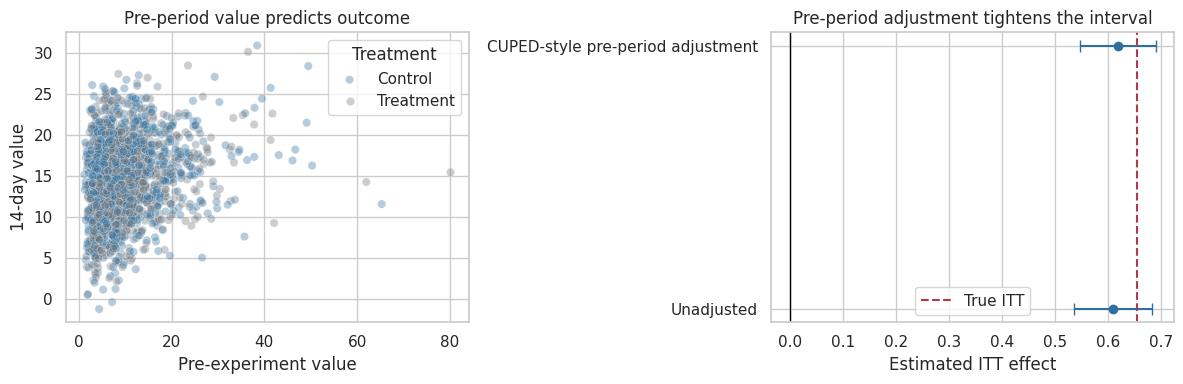

Estimated theta: 0.136


In [20]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=cuped_df.sample(2_000, random_state=15),
    x="pre_value",
    y="value_14d",
    hue="Z",
    alpha=0.35,
    ax=axes[0],
    palette=["#6c757d", "#2f6f9f"],
)
axes[0].set_title("Pre-period value predicts outcome")
axes[0].set_xlabel("Pre-experiment value")
axes[0].set_ylabel("14-day value")
axes[0].legend(title="Treatment", labels=["Control", "Treatment"])

plot_df = cuped_table.copy()
plot_df["lower"] = plot_df["ci_lower"]
plot_df["upper"] = plot_df["ci_upper"]
axes[1].errorbar(
    plot_df["difference"],
    plot_df["method"],
    xerr=[plot_df["difference"] - plot_df["lower"], plot_df["upper"] - plot_df["difference"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
)
axes[1].axvline(true_itt, color="#b23a48", linestyle="--", label="True ITT")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Pre-period adjustment tightens the interval")
axes[1].set_xlabel("Estimated ITT effect")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Estimated theta: {theta:.3f}")

The adjusted and unadjusted point estimates are similar because randomization already identifies the effect. The adjusted standard error is smaller because pre-experiment value explains part of the outcome variation.

The key rule is that variance-reduction covariates must be pre-treatment. Adjusting for post-treatment behavior can change the estimand or introduce bias.

## 10. Product Decision Readout

A product experiment should end with a decision-oriented readout that goes beyond a statistics table.

A practical readout might include:

- experiment status and quality checks;
- primary metric effect and confidence interval;
- guardrail assessment;
- triggered-user diagnostic;
- segment notes;
- recommendation.

Here is a simple rule-based readout for our simulated onboarding experiment.

In [21]:
# Build the summary table used to connect the calculation back to the design question.
primary = metric_table.query("metric == 'value_14d'").iloc[0]
latency = metric_table.query("metric == 'latency_ms'").iloc[0]
support = metric_table.query("metric == 'support_ticket'").iloc[0]
invariant = metric_table.query("metric == 'pre_value'").iloc[0]
srm_p = clean_srm["p_value"].iloc[0]

minimum_practical_value_lift = 0.15
max_latency_increase_ms = 5.0
max_support_ticket_increase = 0.002

checks = pd.DataFrame({
    "check": [
        "SRM quality check",
        "Invariant pre-value metric",
        "Primary metric clears practical threshold",
        "Latency guardrail",
        "Support-ticket guardrail",
    ],
    "value": [
        srm_p,
        invariant["p_value"],
        primary["difference"],
        latency["difference"],
        support["difference"],
    ],
    "criterion": [
        "p-value not extremely small",
        "no meaningful movement expected",
        f"> {minimum_practical_value_lift:.2f}",
        f"< {max_latency_increase_ms:.1f} ms increase",
        f"< {max_support_ticket_increase:.3f} absolute increase",
    ],
    "passes": [
        srm_p > 1e-4,
        invariant["p_value"] > 0.01,
        primary["ci_lower"] > minimum_practical_value_lift,
        latency["ci_upper"] < max_latency_increase_ms,
        support["ci_upper"] < max_support_ticket_increase,
    ],
})
smart_display(checks)

,check,value,criterion,passes
0,SRM quality check,0.482563,p-value not extremely small,True
1,Invariant pre-value metric,0.283387,no meaningful movement expected,True
2,Primary metric clears practical threshold,0.609271,> 0.15,True
3,Latency guardrail,3.622483,< 5.0 ms increase,True
4,Support-ticket guardrail,0.004814,< 0.002 absolute increase,False


In Product Decision Readout, the table is a design check. Unexpected assignment or balance patterns are design problems first and metric problems second.

In [22]:
# Build the summary table used to connect the calculation back to the design question.
recommendation = "Launch" if checks["passes"].all() else "Do not launch yet / iterate"
summary = pd.DataFrame({
    "field": [
        "Recommendation",
        "Primary effect on value_14d",
        "Primary 95% CI",
        "Latency effect",
        "Support ticket effect",
        "SRM p-value",
        "Triggered-user effect",
    ],
    "readout": [
        recommendation,
        f"{primary['difference']:.3f}",
        f"[{primary['ci_lower']:.3f}, {primary['ci_upper']:.3f}]",
        f"{latency['difference']:.3f} ms",
        f"{support['difference']:.4f}",
        f"{srm_p:.4f}",
        f"{triggered_readout['difference']:.3f}",
    ],
})
smart_display(summary)

,field,readout
0,Recommendation,Do not launch yet / iterate
1,Primary effect on value_14d,0.609
2,Primary 95% CI,"[0.536, 0.683]"
3,Latency effect,3.622 ms
4,Support ticket effect,0.0048
5,SRM p-value,0.4826
6,Triggered-user effect,1.314


The simulated experiment improves the primary metric, but the latency guardrail is intentionally tight. Depending on the actual guardrail tolerance, the recommendation may be to optimize performance before launch or ramp to a limited population while monitoring latency.

This is how strong product experimentation should feel: causal, statistical, operational, and decision-oriented.

## 11. Common Product Experimentation Pitfalls

| Pitfall | Why it is dangerous | Practical response |
|---|---|---|
| Randomizing sessions when users return | Users can see both variants | Randomize at user/account level when treatment persists |
| Analyzing event rows as independent | Standard errors become too small | Aggregate to randomization unit or cluster SEs |
| Ignoring SRM | Broken assignment/logging can masquerade as an effect | Automate SRM checks |
| Treating exposure as assignment | Exposure may be post-treatment or selective | Report ITT first; define triggered estimand carefully |
| Metric shopping | False positives become likely | Pre-specify primary and guardrails |
| Looking only at the primary metric | User experience or platform health can degrade | Use guardrails and invariant metrics |
| Launching from tiny segment wins | Subgroups are noisy | Treat as exploratory unless pre-specified and powered |
| Using post-treatment covariates for adjustment | Estimand can change | Use pre-treatment covariates for precision |
| Running overlapping interacting tests blindly | Effects may not be separable | Manage traffic layers and interaction risks |

Crook et al. (2009) discuss several web-experiment pitfalls, and large experimentation systems add automated checks because manual review does not scale well.

## 12. Key Takeaways

- A/B testing is randomized causal inference embedded in a product system.
- Stable assignment is essential; users should not randomly switch variants across visits.
- The cleanest primary estimand is usually the effect of assignment among eligible users.
- Triggered analysis can be useful, but it changes the population and must be defined carefully.
- User-level randomization calls for user-level analysis or clustered uncertainty.
- SRM is a first-line quality check; a severe mismatch can invalidate the readout until explained.
- A/A tests validate the experimentation platform and calibrate false-positive expectations.
- Pre-experiment covariates can reduce variance without changing the causal estimand.
- Product readouts should combine causal estimates, guardrails, invariant checks, and a decision recommendation.

The next notebook will focus on power, minimum detectable effects, sample size, and practical significance: the planning side of product experiments.

## 13. Real-Data Companion: RAND HIE and Experiment Readiness

The simulated A/B test in this lecture is clean because the product system controls assignment and measurement. Real experiments are more awkward. Outcomes are skewed, some units have no activity, baseline health or risk variables still matter for precision, and the dataset rarely arrives in the exact form we wish we had.

The RAND Health Insurance Experiment is a useful realism check. It was a real randomized study of health insurance cost sharing and medical utilization. Here we use it only as a companion exercise: compare outpatient physician visits across more generous and less generous cost-sharing groups, then ask what a real experiment readout would need to report.

The unit is a person-year observation. The outcome is `mdvis`, the number of outpatient physician visits. The comparison below uses a simple low-cost-sharing indicator built from the observed cost-sharing measure. This is a compact teaching use of the RAND data that shows how real randomized data differ from a polished product simulation.

Data source: [statsmodels RAND HIE dataset](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

**How to read this real-data section.** This is a realism check. The dataset helps us inspect balance, timing, support, and model behavior, while the causal claim depends on a credible design story.


**Real-data dataset note.** The RAND Health Insurance Experiment is randomized, but it is not a product A/B test. We use it as a real-data reminder that even randomized studies require careful measurement, baseline summaries, skewed outcome checks, and estimand discipline. The units are people or families in health-insurance plans, the assignment is plan generosity, and outcomes reflect health-care use and spending. The lesson for product experimentation is operational: random assignment is powerful, but the readout still has to explain the unit of analysis, missingness, noisy outcomes, and whether the measured endpoint matches the decision.

,comparison_group,observations,mean_visits,median_visits,zero_visit_share,mean_disease_index
0,Higher cost sharing,9193,2.546,1.0,0.352,11.493
1,Lower cost sharing,10997,3.124,2.0,0.279,11.037


,quantity,estimate,interpretation
0,Unadjusted difference in mean physician visits,0.578000,"Simple randomized contrast, before precision adjustment."
1,Regression-adjusted low-cost-sharing coefficient,0.612000,Precision-adjusted association within this simplified readout.


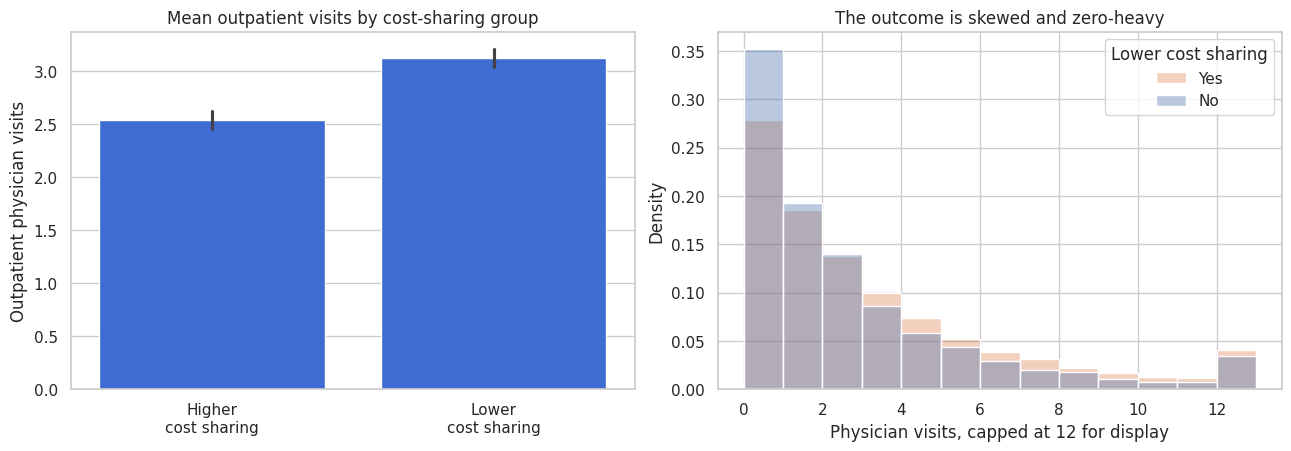

In [23]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True
RAND_HIE_SOURCE = "https://www.statsmodels.org/stable/datasets/generated/randhie.html"

if RUN_REAL_DATA_COMPANION:
    rand_hie = load_statsmodels_randhie().copy()
    rand_hie["low_cost_sharing"] = (rand_hie["lncoins"] <= rand_hie["lncoins"].median()).astype(int)
    rand_hie["health_status"] = np.select(
        [rand_hie["hlthp"] == 1, rand_hie["hlthf"] == 1, rand_hie["hlthg"] == 1],
        ["Poor", "Fair", "Good"],
        default="Other",
    )

    rand_summary = (
        rand_hie.groupby("low_cost_sharing")
        .agg(
            observations=("mdvis", "size"),
            mean_visits=("mdvis", "mean"),
            median_visits=("mdvis", "median"),
            zero_visit_share=("mdvis", lambda x: np.mean(x == 0)),
            mean_disease_index=("disea", "mean"),
        )
        .rename(index={0: "Higher cost sharing", 1: "Lower cost sharing"})
        .reset_index(names="comparison_group")
    )
    smart_display(rand_summary.round(3))

    rand_readout = smf.ols(
        "mdvis ~ low_cost_sharing + physlm + disea + hlthg + hlthf + hlthp",
        data=rand_hie,
    ).fit(cov_type="HC1")

    rand_effect_table = pd.DataFrame(
        [
            {
                "quantity": "Unadjusted difference in mean physician visits",
                "estimate": rand_summary.loc[1, "mean_visits"] - rand_summary.loc[0, "mean_visits"],
                "interpretation": "Simple randomized contrast, before precision adjustment.",
            },
            {
                "quantity": "Regression-adjusted low-cost-sharing coefficient",
                "estimate": rand_readout.params["low_cost_sharing"],
                "interpretation": "Precision-adjusted association within this simplified readout.",
            },
        ]
    )
    smart_display(rand_effect_table.round(3))

    plot_frame = rand_hie.assign(mdvis_capped=rand_hie["mdvis"].clip(upper=12))
    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4), constrained_layout=True)
    sns.barplot(data=rand_hie, x="low_cost_sharing", y="mdvis", errorbar=("ci", 95), ax=axes[0], color="#2563eb")
    axes[0].set_xticklabels(["Higher\ncost sharing", "Lower\ncost sharing"])
    axes[0].set_title("Mean outpatient visits by cost-sharing group")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Outpatient physician visits")

    sns.histplot(
        data=plot_frame,
        x="mdvis_capped",
        hue="low_cost_sharing",
        bins=np.arange(0, 14),
        stat="density",
        common_norm=False,
        alpha=0.38,
        ax=axes[1],
    )
    axes[1].set_title("The outcome is skewed and zero-heavy")
    axes[1].set_xlabel("Physician visits, capped at 12 for display")
    axes[1].set_ylabel("Density")
    axes[1].legend(title="Lower cost sharing", labels=["Yes", "No"])
    plt.show()
else:
    optional_data_note("RAND Health Insurance Experiment", RAND_HIE_SOURCE, "RUN_REAL_DATA_COMPANION")

The real-data companion adds two lessons that do not show up clearly in a clean A/B simulation. First, randomized data can still have skewed outcomes and operationally meaningful baseline risk differences. Randomization protects the causal interpretation of assignment, but the readout still has to deal with noisy measurement and uneven outcome distributions.

Second, a practical experiment report should separate the design from the estimator. The design tells us why the comparison is meaningful. Regression adjustment can improve precision or make the table easier to interpret, but it is not what creates the causal credibility.

## References

Athey, S., & Imbens, G. W. (2017). The econometrics of randomized experiments. *Handbook of Economic Field Experiments*, 73-140. https://doi.org/10.1016/bs.hefe.2016.10.003

Crook, T. R., Frasca, B., Kohavi, R., & Longbotham, R. (2009). Seven pitfalls to avoid when running controlled experiments on the web. *Proceedings of the 15th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1105-1114. https://doi.org/10.1145/1557019.1557139

Guo, Y., & Deng, A. (2015). Flexible online repeated measures experiment. *arXiv*. https://doi.org/10.48550/arxiv.1501.00450

Kohavi, R., Deng, A., Frasca, B., Longbotham, R., Walker, T., & Xu, Y. (2013). Online controlled experiments at large scale. *Proceedings of the 19th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1168-1176. https://doi.org/10.1145/2487575.2488217

Kohavi, R., Henne, R. M., & Sommerfield, D. (2007). Practical guide to controlled experiments on the web. *Proceedings of the 13th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 959-967. https://doi.org/10.1145/1281192.1281295

Kohavi, R., Longbotham, R., Sommerfield, D., & Henne, R. M. (2008). Controlled experiments on the web: Survey and practical guide. *Data Mining and Knowledge Discovery, 18*(1), 140-181. https://doi.org/10.1007/s10618-008-0114-1

Vermeer, L., Anderson, K., & Acebal, M. (2022). Automated sample ratio mismatch (SRM) detection and analysis. *EASE 2022: Evaluation and Assessment in Software Engineering*, 268-269. https://doi.org/10.1145/3530019.3534982

Wong, J., Lewis, R. A., & Wardrop, M. (2019). Efficient computation of linear model treatment effects in an experimentation platform. *arXiv*. https://doi.org/10.48550/arxiv.1910.01305